In [120]:
# ============================================================
# Settings
# ============================================================
n_steps          = 1000      # steps per sloppy-direction walk
base_step_size   = 1   # step size for the most-sloppy direction
sloppy_threshold = 1e-3    # lambda < threshold  ->  sloppy mode
NOISE            = 1e-5    # variance of Gaussian noise added to step vector (0 = off)

Computing H at baseline parameters ...

Eigenvalues (descending):
   1: 8.187e+00
   2: 1.015e-01
   3: 3.544e-04
   4: 2.743e-04
   5: 1.353e-04
   6: 7.765e-09

Found 4 sloppy mode(s)  (lambda < 1.0e-03):
  eigenvector index 5: lambda = 7.765e-09
  eigenvector index 4: lambda = 1.353e-04
  eigenvector index 3: lambda = 2.743e-04
  eigenvector index 2: lambda = 3.544e-04


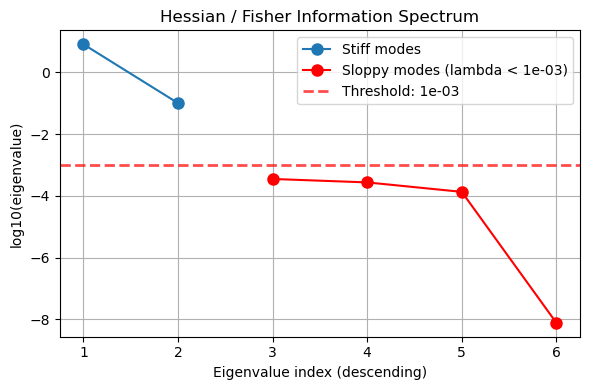

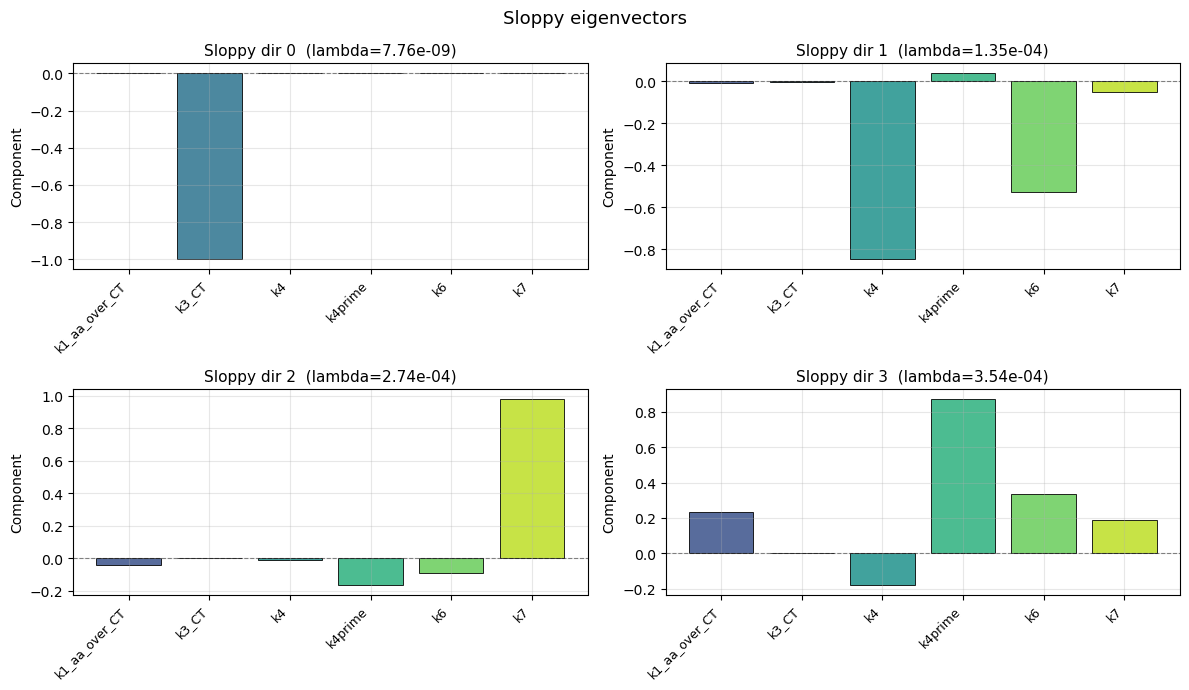

In [121]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.integrate import solve_ivp
from numpy.linalg import eigh, svd

# ─── Parameters ───────────────────────────────────────────────────────────────
p = {
    "k1_aa_over_CT": 0.015,
    "k2":            0.0,
    "k3_CT":         200.0,
    "k4":            180.0,
    "k4prime":       0.018,
    "k5_minusP":     0.0,
    "k6":            1.0,
    "k7":            0.6,
    "k8_minusP":     100.0,
    "k9":            50.0,
    "CT":            1.0,
}

param_names = ["k1_aa_over_CT", "k3_CT", "k4", "k4prime", "k6", "k7"]
P  = len(param_names)
CT = p["CT"]

# ─── ODE right-hand side ──────────────────────────────────────────────────────
def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    return p["k4"] * 2.0 * (M / p["CT"]) / p["CT"]

def f_rhs(t, x, p):
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p["CT"]
    return np.array([
        p["k6"]*M  - p["k8_minusP"]*C2 + p["k9"]*CP,
        -k3*CP*Y   + p["k8_minusP"]*C2 - p["k9"]*CP,
        k3*CP*Y    - pM*F_M(M, p)      + p["k5_minusP"]*M,
        pM*F_M(M, p) - p["k5_minusP"]*M - p["k6"]*M,
        k1 - p["k2"]*Y - k3*CP*Y,
        p["k6"]*M  - p["k7"]*YP,
    ])

def jacobian_fx(x, p):
    C2, CP, pM, M, Y, YP = x
    k3  = p["k3_CT"] / p["CT"]
    dF  = dF_dM(M, p)
    J   = np.zeros((6, 6))
    J[0, 0] = -p["k8_minusP"];   J[0, 1] = p["k9"];            J[0, 3] = p["k6"]
    J[1, 0] =  p["k8_minusP"];   J[1, 1] = -k3*Y - p["k9"];    J[1, 4] = -k3*CP
    J[2, 1] =  k3*Y;             J[2, 2] = -F_M(M, p)
    J[2, 3] = -pM*dF + p["k5_minusP"];                          J[2, 4] =  k3*CP
    J[3, 2] =  F_M(M, p);        J[3, 3] = pM*dF - p["k5_minusP"] - p["k6"]
    J[4, 1] = -k3*Y;             J[4, 4] = -p["k2"] - k3*CP
    J[5, 3] =  p["k6"];          J[5, 5] = -p["k7"]
    return J

def df_dparam(x, p):
    C2, CP, pM, M, Y, YP = x
    dfdh = np.zeros((6, P))
    for j, name in enumerate(param_names):
        df = np.zeros(6)
        if   name == "k1_aa_over_CT": df[4] = p["CT"]
        elif name == "k3_CT":
            c = 1.0 / p["CT"]
            df[1] = -c*CP*Y;  df[2] =  c*CP*Y;  df[4] = -c*CP*Y
        elif name == "k4":
            v = (M / p["CT"])**2;  df[2] = -pM*v;  df[3] = pM*v
        elif name == "k4prime":  df[2] = -pM;         df[3] = pM
        elif name == "k6":       df[0] =  M;   df[3] = -M;  df[5] = M
        elif name == "k7":       df[5] = -YP
        elif name == "k8_minusP": df[0] = -C2;  df[1] = C2
        elif name == "k9":        df[0] =  CP;  df[1] = -CP
        else: raise KeyError(name)
        dfdh[:, j] = df
    return dfdh

# ─── Augmented sensitivity ODE ────────────────────────────────────────────────
def _aug_rhs(t, z, p_local):
    x       = z[:6]
    S       = z[6:].reshape((6, P), order='F')
    xdot    = f_rhs(t, x, p_local)
    A       = jacobian_fx(x, p_local)
    df_dh   = df_dparam(x, p_local)
    df_dlh  = np.zeros_like(df_dh)
    for j, name in enumerate(param_names):
        df_dlh[:, j] = p_local[name] * df_dh[:, j]
    return np.concatenate([xdot, (A @ S + df_dlh).ravel(order='F')])

# ─── H computation ────────────────────────────────────────────────────────────
y0     = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
t_span = (0.0, 100.0)
t_eval = np.linspace(t_span[0], t_span[1], 1001)

# trapezoid quadrature weights over t_eval
_dt     = np.diff(t_eval)
q       = np.zeros(len(t_eval))
q[0]    = _dt[0] / 2.0;  q[-1] = _dt[-1] / 2.0
q[1:-1] = 0.5 * (_dt[:-1] + _dt[1:])

def compute_H_for_params(p_local):
    z0  = np.concatenate([y0, np.zeros(6 * P)])
    sol = solve_ivp(lambda t, z: _aug_rhs(t, z, p_local),
                    t_span, z0, method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError(sol.message)
    m = sol.t.size
    St = np.zeros((6, P, m))
    for i in range(m):
        St[:, :, i] = sol.y[6:, i].reshape((6, P), order='F')
    Tc = t_span[1] - t_span[0]
    W  = np.diag(np.ones(6) / (6.0 * Tc))
    dt_loc   = np.diff(sol.t)
    qw       = np.zeros(m)
    qw[0]    = dt_loc[0] / 2.0;  qw[-1] = dt_loc[-1] / 2.0
    qw[1:-1] = 0.5 * (dt_loc[:-1] + dt_loc[1:])
    H = np.zeros((P, P))
    for i in range(m):
        H += qw[i] * St[:, :, i].T @ W @ St[:, :, i]
    ev, evec = eigh(H)
    return ev[::-1].copy(), evec[:, ::-1].copy()

# ─── Simulation helpers ───────────────────────────────────────────────────────
def simulate_at_params(p_local):
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local),
                    t_span, y0, method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y   # (6, m)

def compute_obs(X):
    C2, CP, pM, M, Y, YP = X
    YT = Y + YP + pM + M
    return YT / CT, M / CT

def sq_diff(a, b):
    return float(q @ (a - b)**2)

# ─── Compute initial H and identify sloppy directions ─────────────────────────
print("Computing H at baseline parameters ...")
eigvals, eigvecs = compute_H_for_params(p)

print("\nEigenvalues (descending):")
for i, lam in enumerate(eigvals):
    print(f"  {i+1:2d}: {lam:.3e}")

sloppy_indices = np.where(eigvals < sloppy_threshold)[0]
# order: most sloppy first (eigvals descending, so largest index = smallest lambda)
sloppy_indices = sloppy_indices[::-1]
n_sloppy = len(sloppy_indices)
print(f"\nFound {n_sloppy} sloppy mode(s)  (lambda < {sloppy_threshold:.1e}):")
for idx in sloppy_indices:
    print(f"  eigenvector index {idx}: lambda = {eigvals[idx]:.3e}")

# baseline simulation
X_base          = simulate_at_params(p)
YT_base, M_base = compute_obs(X_base)

# ─── Spectrum plot ────────────────────────────────────────────────────────────
sloppy_mask  = eigvals < sloppy_threshold
x_idx        = np.arange(1, P + 1)
log_eigvals  = np.log10(np.maximum(eigvals, 1e-300))

plt.figure(figsize=(6, 4))
plt.plot(x_idx[~sloppy_mask], log_eigvals[~sloppy_mask], 'o-', color='C0',
         markersize=8, label='Stiff modes')
if sloppy_mask.any():
    plt.plot(x_idx[sloppy_mask], log_eigvals[sloppy_mask], 'o-', color='red',
             markersize=8, label=f'Sloppy modes (lambda < {sloppy_threshold:.0e})')
plt.axhline(np.log10(sloppy_threshold), color='red', linestyle='--',
            linewidth=2, alpha=0.7, label=f'Threshold: {sloppy_threshold:.0e}')
plt.xlabel("Eigenvalue index (descending)")
plt.ylabel("log10(eigenvalue)")
plt.title("Hessian / Fisher Information Spectrum")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ─── Sloppy eigenvector bar plots ─────────────────────────────────────────────
n_show = min(4, n_sloppy)
if n_show == 0:
    print("No sloppy eigenvectors to display.")
else:
    ncols_b = min(n_show, 2)
    nrows_b = (n_show + ncols_b - 1) // ncols_b
    fig, axes = plt.subplots(nrows_b, ncols_b, figsize=(6*ncols_b, 3.5*nrows_b), squeeze=False)
    x_pos    = np.arange(P)
    bar_clrs = plt.cm.viridis(np.linspace(0.25, 0.9, P))
    for k, eig_idx in enumerate(sloppy_indices[:n_show]):
        ax = axes[k // ncols_b, k % ncols_b]
        v  = eigvecs[:, eig_idx]
        ax.bar(x_pos, v, color=bar_clrs, edgecolor='black', linewidth=0.7, alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.45)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(param_names, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Component')
        ax.set_title(f'Sloppy dir {k}  (lambda={eigvals[eig_idx]:.2e})', fontsize=11)
        ax.grid(True, alpha=0.3)
    for k in range(n_show, nrows_b * ncols_b):
        axes[k // ncols_b, k % ncols_b].set_visible(False)
    plt.suptitle('Sloppy eigenvectors', fontsize=13)
    plt.tight_layout();  plt.show()

In [ ]:
# ============================================================
# Multi-direction walk  —  one walk per sloppy eigenvector
# ============================================================
# At every step: recompute H at the current parameter position,
# find the walk_idx-th sloppy eigenvector from that fresh H,
# align its sign with the previous step's direction, then step.
#
# Step size determined by step_size_for_lambda(lambda_current).
# Optional Gaussian noise (variance = NOISE) on the step vector.
# ============================================================

n_walk = min(4, n_sloppy)
if n_walk == 0:
    raise RuntimeError("No sloppy directions found. Adjust sloppy_threshold.")

def step_size_for_lambda(lam):
    ratio = eigvals[sloppy_indices[0]] / lam
    scaled_step = base_step_size * ratio**(1/2)
    return scaled_step

all_walks = []

for walk_idx in range(n_walk):
    initial_eig_idx = sloppy_indices[walk_idx]
    lambda_init     = eigvals[initial_eig_idx]
    # reference direction for sign alignment (updated every step)
    v_ref = eigvecs[:, initial_eig_idx].copy()
    step_size_print = step_size_for_lambda(lambda_init)

    print(f"\n=== Walk {walk_idx}: sloppy dir {walk_idx} | "
          f"initial lambda={lambda_init:.3e} ===", f"stepsize: {step_size_print:.3e}")

    p_current  = copy.deepcopy(p)
    param_hist = [copy.deepcopy(p_current)]
    obs_hist   = [(YT_base.copy(), M_base.copy())]
    eigvec_hist     = []   # sign-aligned eigenvector used at each step
    eigval_hist     = []   # eigenvalue of the tracked direction
    all_eigvals_hist = []  # full eigenvalue spectrum at each step

    for step in range(1, n_steps + 1):
        # --- recompute H at current position ---
        ev_loc, evec_loc = compute_H_for_params(p_current)

        # pick the walk_idx-th sloppy direction (most sloppy = index 0)
        sloppy_loc = np.where(ev_loc < sloppy_threshold)[0][::-1]  # most sloppy first
        if len(sloppy_loc) == 0:
            print(f"  step {step}: no sloppy directions found — stopping walk.")
            break
        dir_idx  = sloppy_loc[min(walk_idx, len(sloppy_loc) - 1)]
        v_n      = evec_loc[:, dir_idx].copy()
        lambda_n = ev_loc[dir_idx]

        # align sign with previous direction so the walk doesn't randomly reverse
        if np.dot(v_n, v_ref) < 0:
            v_n = -v_n
        v_ref = v_n.copy()

        eigvec_hist.append(v_n.copy())
        eigval_hist.append(lambda_n)
        all_eigvals_hist.append(ev_loc.copy())
        step_size_n = step_size_for_lambda(lambda_n)
        dlogh       = step_size_n * v_n
        if NOISE > 0:
            dlogh = dlogh + np.random.normal(0, np.sqrt(NOISE), size=P)

        p_next = copy.deepcopy(p_current)
        for j, name in enumerate(param_names):
            p_next[name] *= np.exp(dlogh[j])

        X_next          = simulate_at_params(p_next)
        YT_next, M_next = compute_obs(X_next)

        param_hist.append(copy.deepcopy(p_next))
        obs_hist.append((YT_next.copy(), M_next.copy()))
        p_current = p_next

        if step % 10 == 0:
            print(f"  step {step}/{n_steps} | lambda={lambda_n:.3e}")

    all_walks.append({
        'walk_idx':      walk_idx,
        'eig_idx':       initial_eig_idx,
        'lambda_n':      lambda_init,
        'step_size':     step_size_for_lambda(lambda_init),
        'param_history': param_hist,
        'obs_history':   obs_hist,
        'eigvec_hist':       eigvec_hist,
        'eigval_hist':       eigval_hist,
        'all_eigvals_hist':  all_eigvals_hist,
    })

print("\nAll walks complete.")


=== Walk 0: sloppy dir 0 | initial lambda=7.765e-09 === stepsize: 1.000e+00
  step 10/1000 | lambda=2.988e-06
  step 20/1000 | lambda=6.171e-06
  step 30/1000 | lambda=9.411e-06
  step 40/1000 | lambda=1.301e-05
  step 50/1000 | lambda=1.702e-05
  step 60/1000 | lambda=2.106e-05
  step 70/1000 | lambda=2.663e-05
  step 80/1000 | lambda=3.302e-05
  step 90/1000 | lambda=3.960e-05
  step 100/1000 | lambda=4.567e-05
  step 110/1000 | lambda=5.291e-05
  step 120/1000 | lambda=5.878e-05
  step 130/1000 | lambda=6.316e-05
  step 140/1000 | lambda=6.638e-05
  step 150/1000 | lambda=6.825e-05
  step 160/1000 | lambda=6.840e-05


/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_95187/1793339755.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_w   = cm.get_cmap('plasma', n_rec)


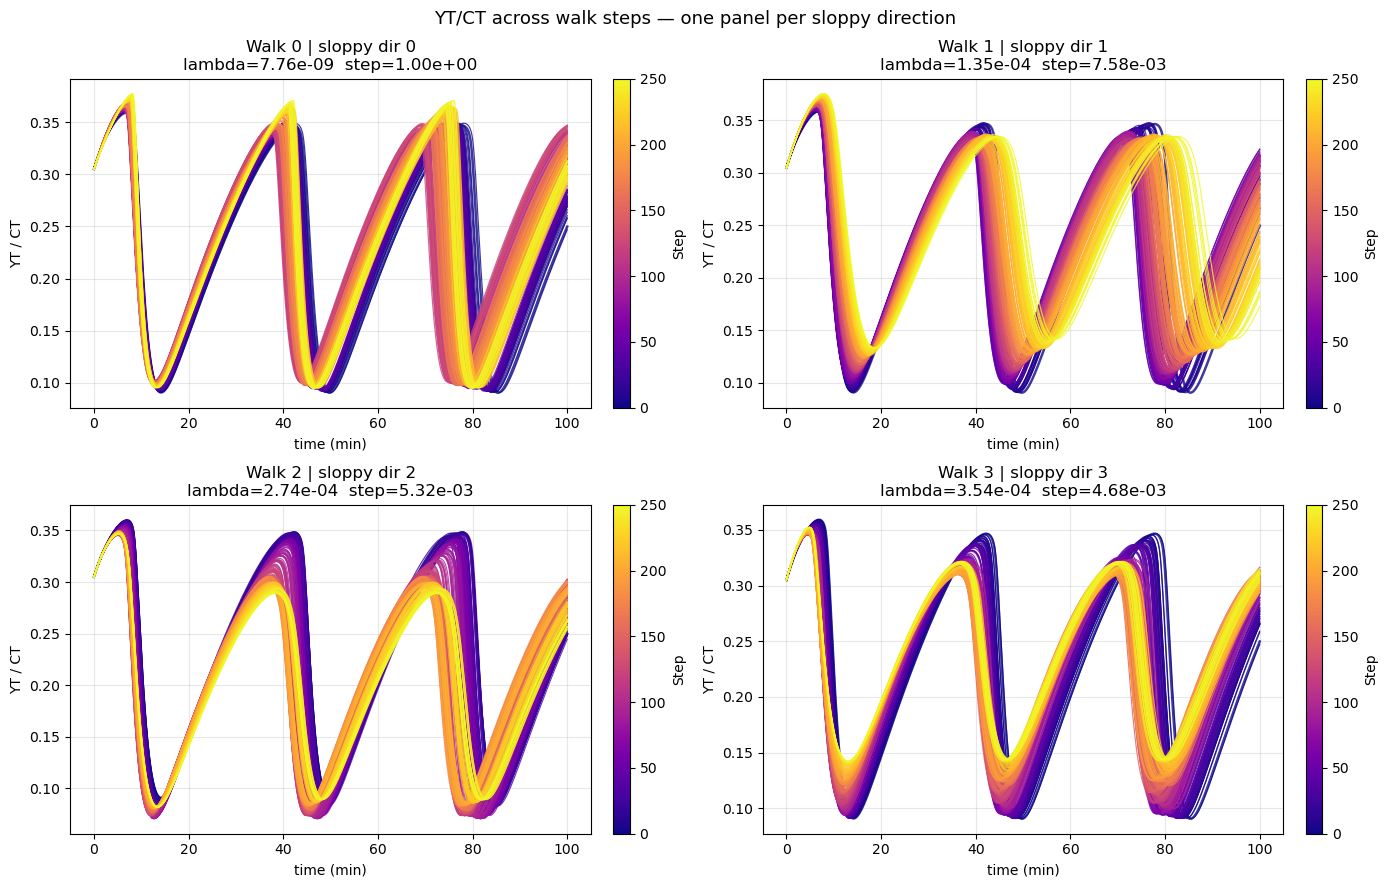

/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_95187/1793339755.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_w   = cm.get_cmap('viridis', n_rec)


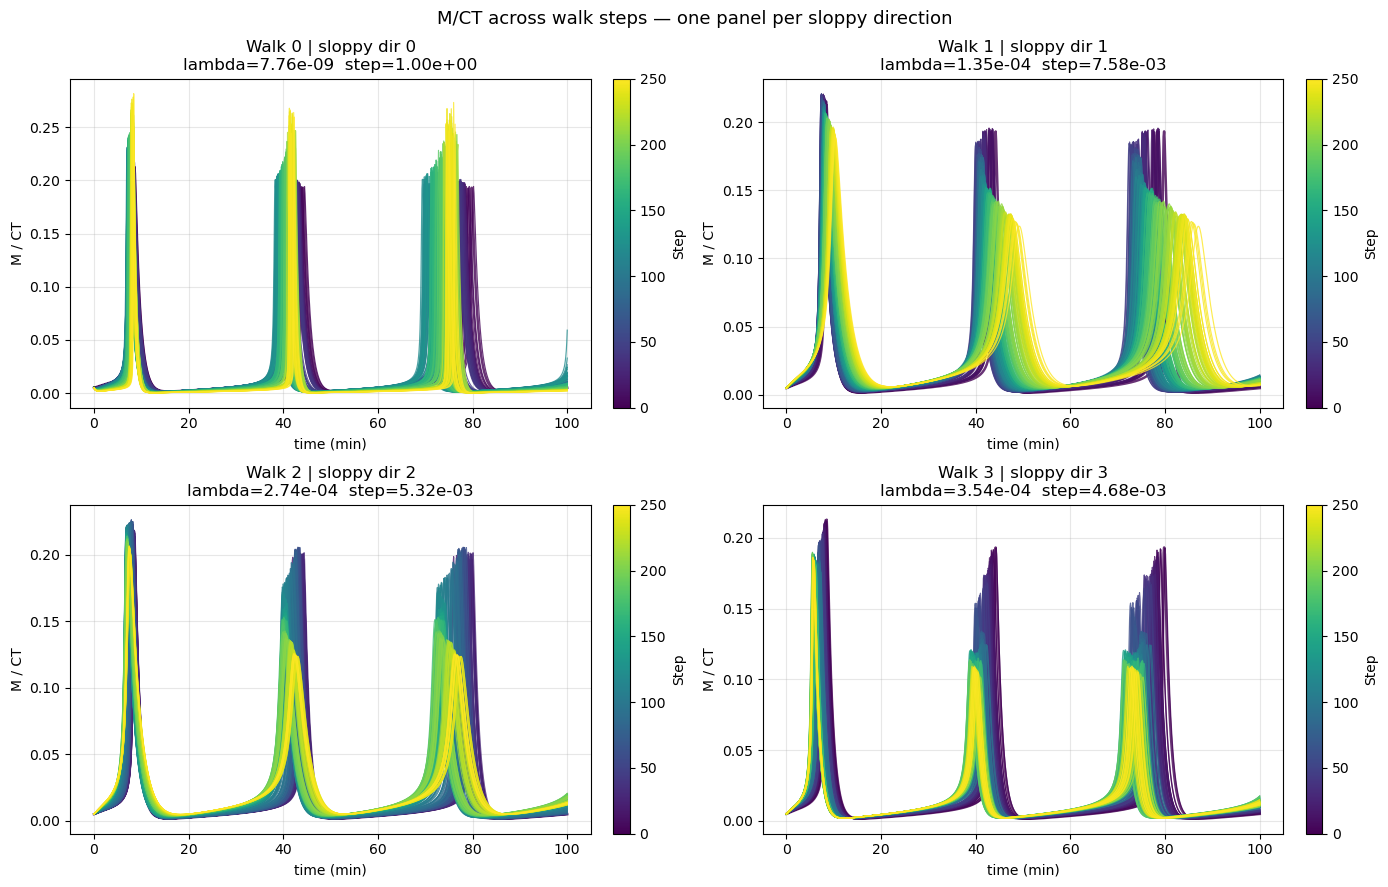

In [ ]:
# ============================================================
# 2x2  YT/CT time-series overlay — one panel per sloppy direction
# ============================================================
n_w   = len(all_walks)
ncols = min(n_w, 2)
nrows = (n_w + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.5*nrows), squeeze=False)

for walk in all_walks:
    wid      = walk['walk_idx']
    obs_hist = walk['obs_history']
    n_rec    = len(obs_hist)
    cmap_w   = cm.get_cmap('plasma', n_rec)
    norm_w   = mcolors.Normalize(vmin=0, vmax=n_rec - 1)

    ax = axes[wid // ncols, wid % ncols]
    for i, (YT_i, _) in enumerate(obs_hist):
        lw = 1.8 if i == 0 else 0.85
        ax.plot(t_eval, YT_i, color=cmap_w(norm_w(i)), lw=lw, alpha=0.8)

    sm = plt.cm.ScalarMappable(cmap=cmap_w, norm=norm_w)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Step', fraction=0.035, pad=0.04)
    ax.set_xlabel('time (min)')
    ax.set_ylabel('YT / CT')
    ax.set_title(f'Walk {wid} | sloppy dir {wid}\n'
                 f'lambda={walk["lambda_n"]:.2e}  step={walk["step_size"]:.2e}')
    ax.grid(True, alpha=0.3)

for k in range(n_w, nrows * ncols):
    axes[k // ncols, k % ncols].set_visible(False)

plt.suptitle('YT/CT across walk steps — one panel per sloppy direction', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 2x2  M/CT time-series overlay
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.5*nrows), squeeze=False)

for walk in all_walks:
    wid      = walk['walk_idx']
    obs_hist = walk['obs_history']
    n_rec    = len(obs_hist)
    cmap_w   = cm.get_cmap('viridis', n_rec)
    norm_w   = mcolors.Normalize(vmin=0, vmax=n_rec - 1)

    ax = axes[wid // ncols, wid % ncols]
    for i, (_, M_i) in enumerate(obs_hist):
        lw = 1.8 if i == 0 else 0.85
        ax.plot(t_eval, M_i, color=cmap_w(norm_w(i)), lw=lw, alpha=0.8)

    sm = plt.cm.ScalarMappable(cmap=cmap_w, norm=norm_w)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Step', fraction=0.035, pad=0.04)
    ax.set_xlabel('time (min)')
    ax.set_ylabel('M / CT')
    ax.set_title(f'Walk {wid} | sloppy dir {wid}\n'
                 f'lambda={walk["lambda_n"]:.2e}  step={walk["step_size"]:.2e}')
    ax.grid(True, alpha=0.3)

for k in range(n_w, nrows * ncols):
    axes[k // ncols, k % ncols].set_visible(False)

plt.suptitle('M/CT across walk steps — one panel per sloppy direction', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_95187/145764486.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_w = cm.get_cmap('viridis', n_rec)


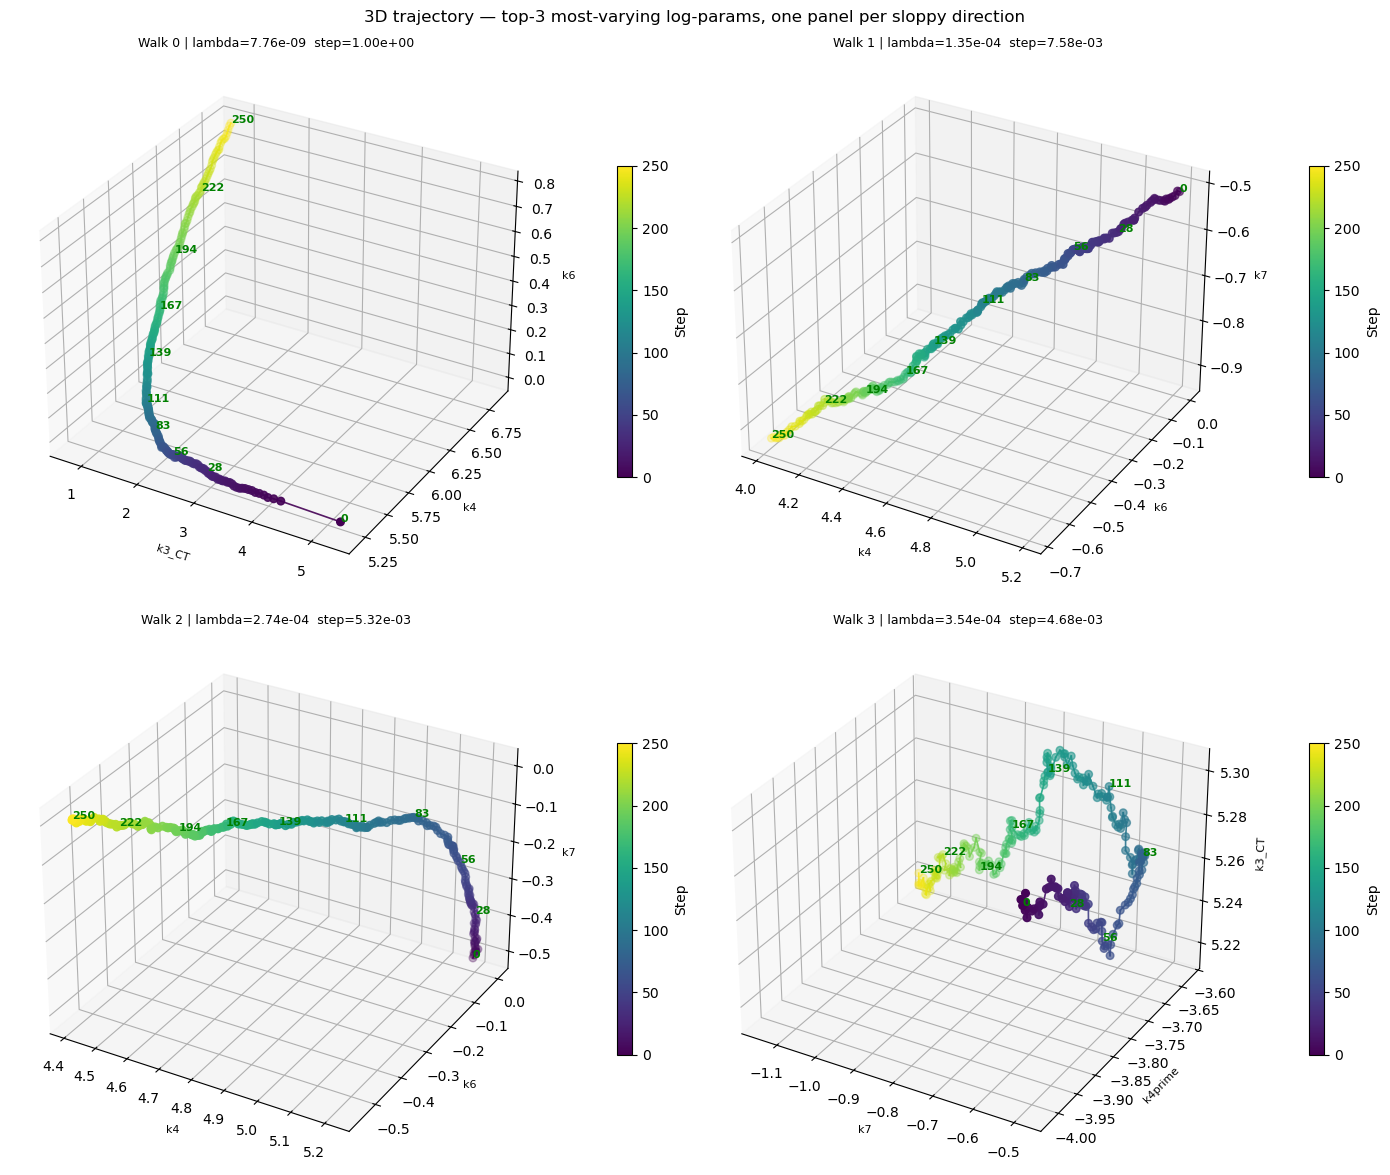

/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_95187/145764486.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_w = cm.get_cmap('viridis', n_rec)
/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_95187/145764486.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_w = cm.get_cmap('viridis', n_rec)
/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_95187/145764486.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap

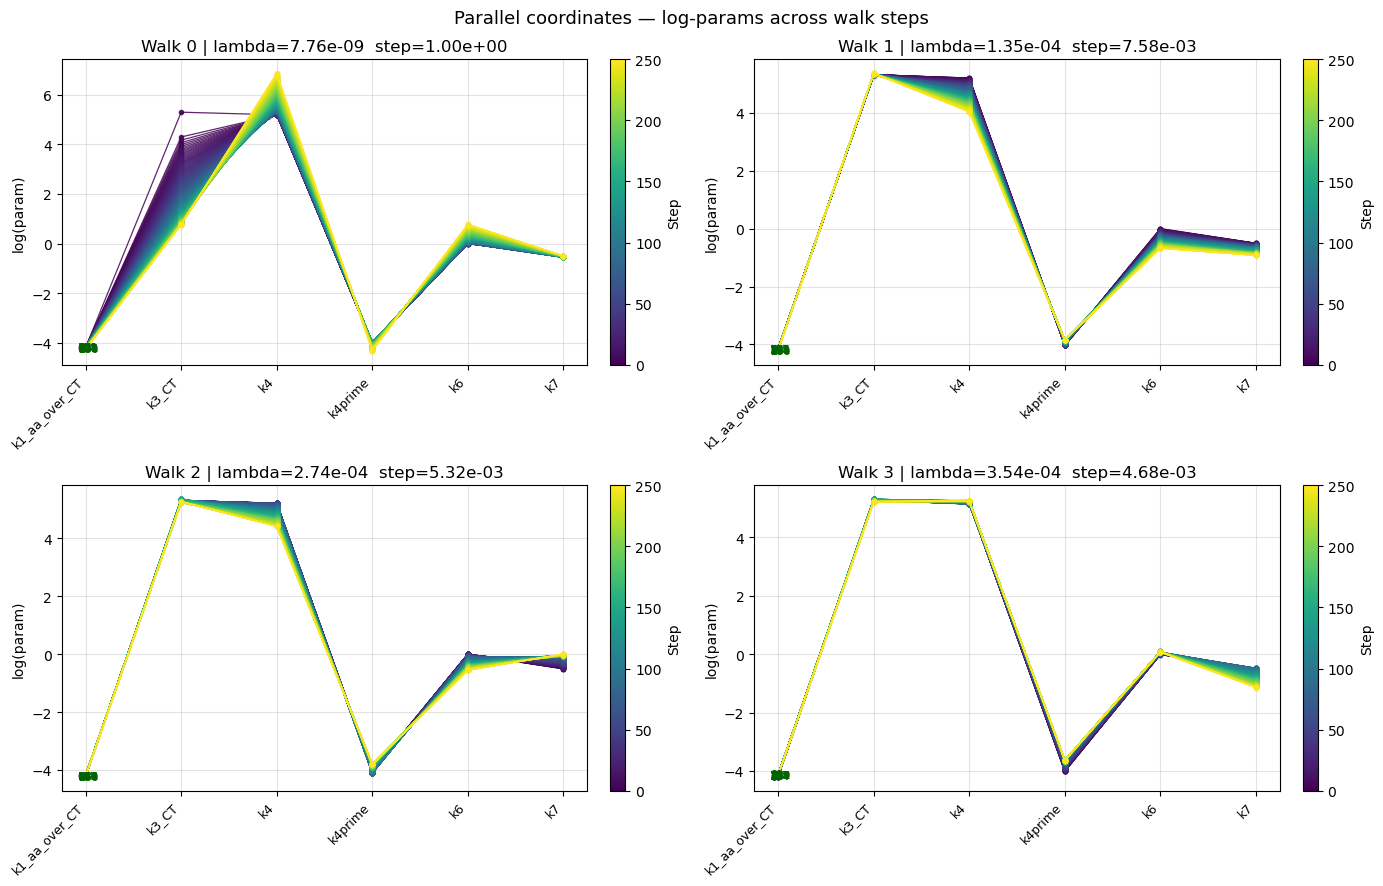

In [ ]:
# ── Figure 2: 3D trajectory of top-3 most-varying log-params  2×2 ────────────────────
# Axes: x = most varying log-param, y = 2nd, z = 3rd most varying.
# Variation measured as |log(p_end) - log(p_start)| per parameter per walk.
from mpl_toolkits.mplot3d import Axes3D  # noqa

n_w   = len(all_walks)
ncols = min(n_w, 2)
nrows = (n_w + ncols - 1) // ncols

fig = plt.figure(figsize=(7*ncols, 6*nrows))

for walk in all_walks:
    wid   = walk['walk_idx']
    ph    = walk['param_history']
    n_rec = len(ph)

    # top-3 most-varying log-params: x = most varying, z = 3rd most varying
    log_v1   = np.array([np.log(ph[0][name])  for name in param_names])
    log_v2   = np.array([np.log(ph[-1][name]) for name in param_names])
    log_diff = np.abs(log_v2 - log_v1)
    top3_idx   = np.argsort(log_diff)[-3:][::-1]   # descending: most varying first
    top3_names = [param_names[i] for i in top3_idx]

    coords = np.array([[np.log(pd[name]) for name in top3_names] for pd in ph])

    cmap_w = cm.get_cmap('viridis', n_rec)
    norm_w = mcolors.Normalize(vmin=0, vmax=n_rec - 1)
    sm     = plt.cm.ScalarMappable(cmap=cmap_w, norm=norm_w)
    sm.set_array([])

    ax = fig.add_subplot(nrows, ncols, wid + 1, projection='3d')

    # colored line segments step by step
    for i in range(n_rec - 1):
        ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2],
                '-', color=cmap_w(norm_w(i)), alpha=0.9, linewidth=1.2)

    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
               c=np.arange(n_rec), cmap=cmap_w, norm=norm_w, s=30, zorder=3)

    # step-index labels at ~10 evenly-spaced positions
    label_idx = np.unique(np.round(np.linspace(0, n_rec - 1, min(10, n_rec))).astype(int))
    for k in label_idx:
        ax.text(coords[k, 0], coords[k, 1], coords[k, 2],
                f'{k}', fontsize=8, color='green', weight='bold')

    fig.colorbar(sm, ax=ax, label='Step', fraction=0.025, pad=0.12, shrink=0.65)
    ax.set_xlabel(top3_names[0], fontsize=8)
    ax.set_ylabel(top3_names[1], fontsize=8)
    ax.set_zlabel(top3_names[2], fontsize=8)
    ax.set_title(f'Walk {wid} | lambda={walk["lambda_n"]:.2e}  step={walk["step_size"]:.2e}',
                 fontsize=9)

for k in range(n_w, nrows * ncols):
    fig.add_subplot(nrows, ncols, k + 1).set_visible(False)

plt.suptitle('3D trajectory — top-3 most-varying log-params, one panel per sloppy direction',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Parallel coordinates  2×2 — all log-params across steps ──────────────────
# Each line is one walk step; x-axis = parameter, y-axis = log(value).
# Matches the style of TysonSloppyOneDirection.

n_w   = len(all_walks)
ncols = min(n_w, 2)
nrows = (n_w + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.5*nrows), squeeze=False)
xs = np.arange(P)

for walk in all_walks:
    wid   = walk['walk_idx']
    ph    = walk['param_history']
    n_rec = len(ph)

    L      = np.array([[np.log(pd[name]) for name in param_names] for pd in ph])
    cmap_w = cm.get_cmap('viridis', n_rec)
    norm_w = mcolors.Normalize(vmin=0, vmax=n_rec - 1)

    ax = axes[wid // ncols, wid % ncols]
    for i in range(n_rec):
        ax.plot(xs, L[i, :], '-o', color=cmap_w(norm_w(i)),
                alpha=0.85, markersize=3, linewidth=0.9)

    # step-index labels at ~10 evenly-spaced steps
    label_idx = np.unique(np.round(np.linspace(0, n_rec - 1, min(10, n_rec))).astype(int))
    for k in label_idx:
        ax.text(xs[0] - 0.08, L[k, 0], f'{k}', fontsize=7,
                verticalalignment='center', color='darkgreen', weight='bold')

    sm = plt.cm.ScalarMappable(cmap=cmap_w, norm=norm_w)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Step', fraction=0.035, pad=0.04)

    ax.set_xticks(xs)
    ax.set_xticklabels(param_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('log(param)')
    ax.set_title(f'Walk {wid} | lambda={walk["lambda_n"]:.2e}  step={walk["step_size"]:.2e}')
    ax.grid(True, alpha=0.35)

for k in range(n_w, nrows * ncols):
    axes[k // ncols, k % ncols].set_visible(False)

plt.suptitle('Parallel coordinates — log-params across walk steps', fontsize=13)
plt.tight_layout()
plt.show()

# ── All walks in joint PCA space — single 3D plot ────────────────────────────
# Center all trajectories by the common starting point (baseline params).
# PCA on the combined data finds axes that best separate the four walks.

origin  = np.array([np.log(p[name]) for name in param_names])
all_L   = []
for walk in all_walks:
    ph = walk['param_history']
    L  = np.array([[np.log(pd[name]) for name in param_names] for pd in ph])
    all_L.append(L)

L_combined = np.vstack(all_L) - origin          # centre at baseline
_, svals, Vt = svd(L_combined, full_matrices=False)
var_exp = svals[:3]**2 / (np.sum(svals**2) + 1e-30) * 100.0

clrs = plt.cm.tab10(np.linspace(0, 1, len(all_walks)))

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

for wi, (walk, L) in enumerate(zip(all_walks, all_L)):
    scores = (L - origin) @ Vt[:3].T    # (n_rec, 3)
    n_rec  = scores.shape[0]
    # gradient alpha: faint early, opaque late
    for i in range(n_rec - 1):
        alpha = 0.35 + 0.65 * i / max(n_rec - 2, 1)
        ax.plot(scores[i:i+2, 0], scores[i:i+2, 1], scores[i:i+2, 2],
                '-', color=clrs[wi], alpha=alpha, linewidth=1.8)
    # start marker
    ax.scatter(*scores[0],  marker='o', s=60,  color=clrs[wi], edgecolor='black',
               linewidth=0.8, zorder=5)
    # end marker
    ax.scatter(*scores[-1], marker='X', s=100, color=clrs[wi], edgecolor='black',
               linewidth=0.8, zorder=5)
    dom   = param_names[int(np.argmax(np.abs(walk['eigvec_hist'][0])))]
    ax.plot([], [], '-', color=clrs[wi],
            label=f'Walk {wi} | {dom}  λ={walk["lambda_n"]:.2e}')

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({var_exp[2]:.1f}%)')
ax.set_title('All walks — joint PCA of log-parameter trajectories\n(centred at baseline; o = start, X = end)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

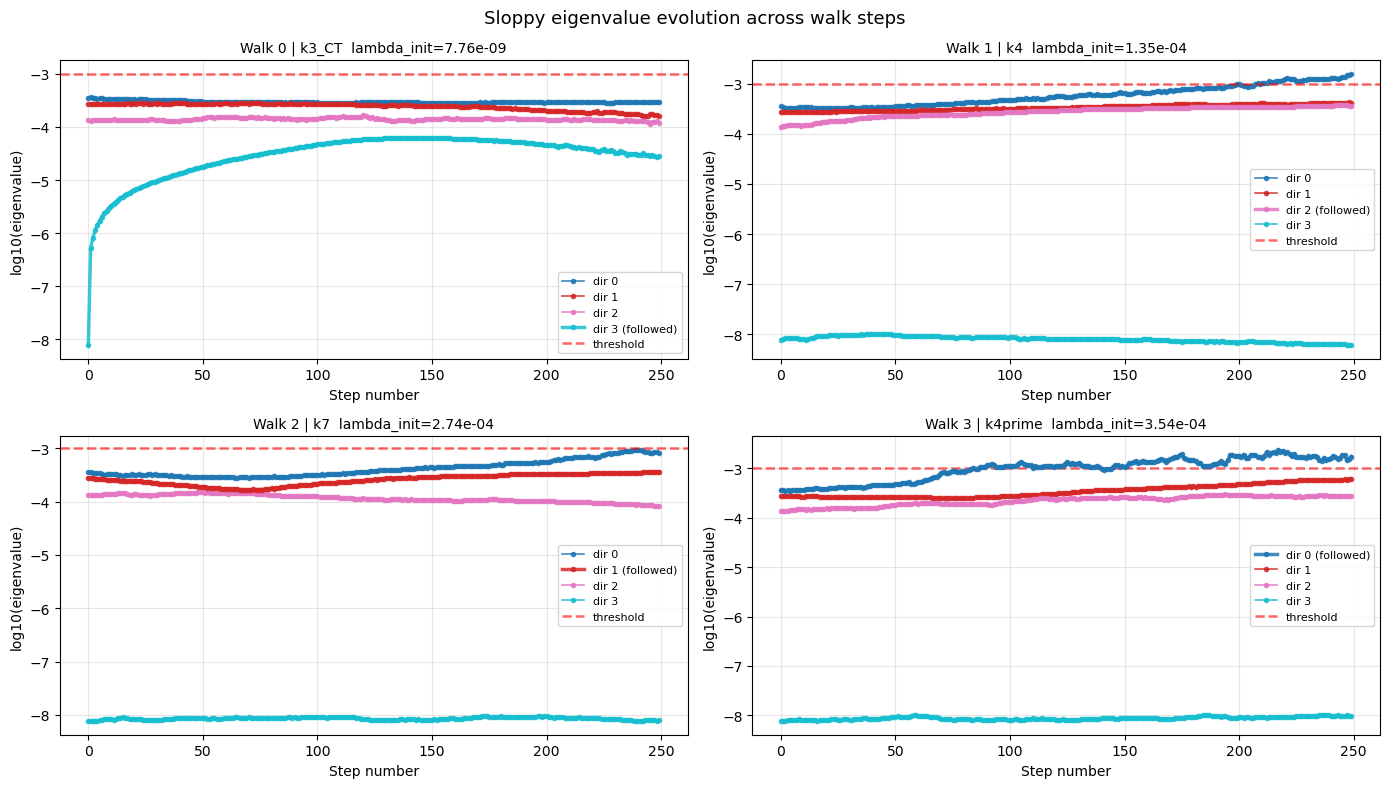

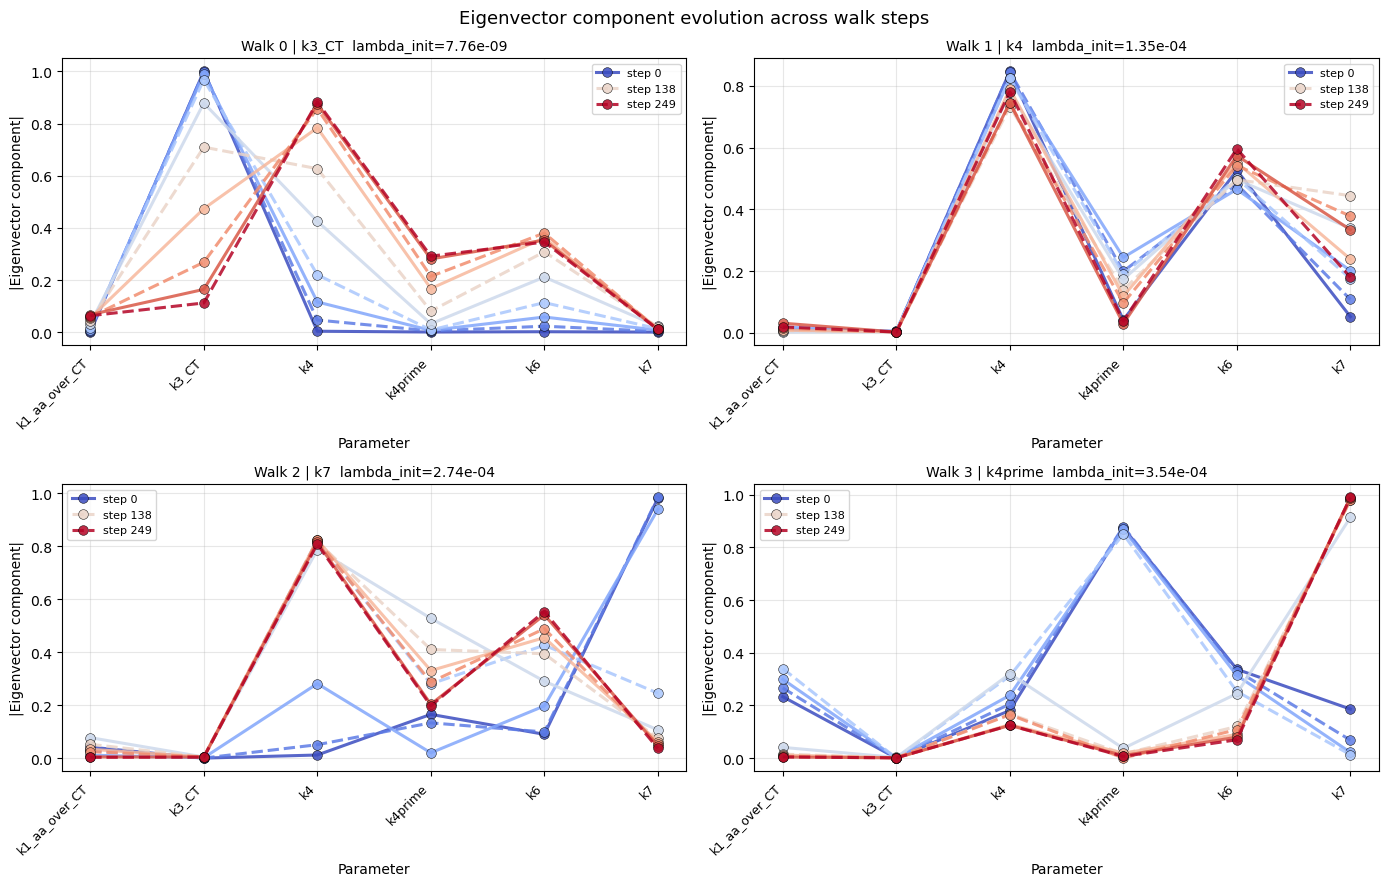

In [ ]:
# ── Eigenvalue evolution  2×2 — all sloppy eigenvalues, one panel per walk ───
n_w   = len(all_walks)
ncols = min(n_w, 2)
nrows = (n_w + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4*nrows), squeeze=False)

for walk in all_walks:
    wid = walk['walk_idx']
    aeh = walk['all_eigvals_hist']   # list of full ev_loc arrays, one per step
    if len(aeh) == 0:
        continue
    steps = np.arange(len(aeh))

    # sloppy modes identified at step 0 (last n_sloppy entries in descending array)
    sloppy_at_0 = np.where(aeh[0] < sloppy_threshold)[0]  # indices in ev_loc
    clrs_modes  = plt.cm.tab10(np.linspace(0, 1, max(len(sloppy_at_0), 1)))

    ax  = axes[wid // ncols, wid % ncols]
    dom = param_names[int(np.argmax(np.abs(walk['eigvec_hist'][0])))]

    for mi, eig_idx in enumerate(sloppy_at_0):
        ev_track = np.array([aeh[s][eig_idx] for s in range(len(aeh))])
        # highlight which mode this walk is following
        lw     = 2.5 if eig_idx == walk['eig_idx'] else 1.2
        zorder = 3   if eig_idx == walk['eig_idx'] else 2
        label  = (f'dir {mi} (followed)' if eig_idx == walk['eig_idx']
                  else f'dir {mi}')
        ax.plot(steps, np.log10(np.maximum(ev_track, 1e-300)),
                'o-', color=clrs_modes[mi], linewidth=lw, markersize=3,
                alpha=0.85, label=label, zorder=zorder)

    ax.axhline(np.log10(sloppy_threshold), color='red', linestyle='--',
               linewidth=1.8, alpha=0.6, label='threshold')
    ax.set_xlabel('Step number')
    ax.set_ylabel('log10(eigenvalue)')
    ax.set_title(f'Walk {wid} | {dom}  lambda_init={walk["lambda_n"]:.2e}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for k in range(n_w, nrows * ncols):
    axes[k // ncols, k % ncols].set_visible(False)

plt.suptitle('Sloppy eigenvalue evolution across walk steps', fontsize=13)
plt.tight_layout()
plt.show()

# ── Eigenvector component evolution  2×2 ─────────────────────────────────────
# Each panel = one sloppy-direction walk.
# 10 evenly-spaced steps sampled; lines coloured blue (early) → red (late).
# y-axis = |eigenvector component|, x-axis = parameter.

n_w   = len(all_walks)
ncols = min(n_w, 2)
nrows = (n_w + ncols - 1) // ncols
n_sample = 10

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.5*nrows), squeeze=False)

for walk in all_walks:
    wid        = walk['walk_idx']
    evh        = walk['eigvec_hist']   # list of P-vectors, one per step
    evlh       = walk['eigval_hist']
    n_steps_w  = len(evh)
    if n_steps_w == 0:
        continue

    sample_idx = np.unique(np.round(np.linspace(0, n_steps_w - 1, min(n_sample, n_steps_w))).astype(int))

    ax = axes[wid // ncols, wid % ncols]
    x_pos = np.arange(P)

    for i, si in enumerate(sample_idx):
        v_abs  = np.abs(evh[si])
        color  = plt.cm.coolwarm(i / max(1, len(sample_idx) - 1))
        ls     = '-' if i % 2 == 0 else '--'
        label  = f'step {si}' if i in [0, len(sample_idx)//2, len(sample_idx)-1] else None
        ax.plot(x_pos, v_abs, marker='o', linestyle=ls, color=color,
                label=label, linewidth=2.2, markersize=7, alpha=0.85,
                markeredgecolor='black', markeredgewidth=0.4)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(param_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('|Eigenvector component|')
    ax.set_xlabel('Parameter')
    dominant = param_names[int(np.argmax(np.abs(evh[0])))]
    ax.set_title(f'Walk {wid} | {dominant}  lambda_init={walk["lambda_n"]:.2e}', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

for k in range(n_w, nrows * ncols):
    axes[k // ncols, k % ncols].set_visible(False)

plt.suptitle('Eigenvector component evolution across walk steps', fontsize=13)
plt.tight_layout()
plt.show()